In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import seaborn as sns

from enum import Enum

In [2]:
# Dictionary to hold our parsed data before converting to a DataFrame
# Format: { 'problem_name': { ('group', 'metric_name'): value } }
data_dict = {}
current_problem = None

# Define the prefixes we want to group by
prefixes = ['num_', 'dd_', 'ar_', 'ggraph_', 'solve_', 'tr_']

def read_into_data_dict(file):
    for line in file:
        line = line.strip()
                    
        if not line:
            continue
        
        # Set the current problem name for the row index
        if line.startswith("BEGINPROBLEM:"):
            current_problem = line.split(":", 1)[1]
            data_dict[current_problem] = {}
            continue
        
        if "=" in line and current_problem is not None:
            key, value_str = line.split("=", 1)
            
            # Parse lists or integers
            if value_str.startswith("[") and value_str.endswith("]"):
                inner_values = value_str[1:-1].strip()
                if inner_values:
                    parsed_value = [int(x) for x in inner_values.split(",")]
                else:
                    parsed_value = []
            else:
                parsed_value = int(value_str)
            
            # Determine 3-level grouping (Group, Subgroup, Metric)
            group = "other"
            subgroup = "base"
            metric = key
            
            for pref in prefixes:
                if key.startswith(pref):
                    group = pref
                    
                    # Further group specific dd_ metrics into sub-categories
                    if key.startswith("dd_thm_matches:"):
                        subgroup = "thm_matches"
                        metric = key.split(":", 1)[1] # Strip prefix for cleaner column names
                    elif key.startswith("dd_thm_duration:"):
                        subgroup = "thm_duration"
                        metric = key.split(":", 1)[1] # Strip prefix for cleaner column names
                    
                    break
            
            # Store data with a 3-part tuple key for the MultiIndex
            data_dict[current_problem][(group, subgroup, metric)] = parsed_value

In [3]:
file1 = open("imo/profiler.txt", "r")
read_into_data_dict(file1)
file2 = open("110-problems/profiler.txt", "r")
read_into_data_dict(file2)

In [4]:
df = pd.DataFrame.from_dict(data_dict, orient='index')
    
# Convert the tuple columns into a 3-level pandas MultiIndex
if not df.empty:
    df.columns = pd.MultiIndex.from_tuples(df.columns, names=['Group', 'Subgroup', 'Metric'])

In [5]:
N = len(df)
df.head()

Group              num_                                solve_  \
Subgroup           base                                  base   
Metric      num_success num_params num_duration solve_success   
imo-2000-1            1          6          178             1   
imo-2002-2a           1          5          134             1   
imo-2002-2b           1          5          259             1   
imo-2003-4            1          6          199             1   
imo-2004-1            1          6          176             1   

Group                                              \
Subgroup                                            
Metric      solve_total_duration solve_iterations   
imo-2000-1               5330119                4   
imo-2002-2a              4401528                3   
imo-2002-2b               426213                2   
imo-2003-4               9165030                3   
imo-2004-1               3885111                4   

Group                                       dd_                           \
Subgroup                                   base                            
Metric                              dd_duration           dd_total_preds   
imo-2000-1    [40942, 942451, 1401769, 2537144]  [243, 1815, 2278, 4176]   
imo-2002-2a            [14373, 265680, 3912170]         [316, 844, 2964]   
imo-2002-2b                     [14764, 264691]               [316, 846]   
imo-2003-4           [130420, 3373692, 5234415]        [395, 4189, 5190]   
imo-2004-1   [20690, 1032314, 1018425, 1524870]  [317, 1303, 1416, 1707]   

Group                                               ...               ar_  \
Subgroup            thm_duration                    ...              base   
Metric          circle_coll_perp       circle_cong  ...     ar_total_rows   
imo-2000-1    [8, 179, 181, 201]   [1, 50, 49, 59]  ...  [42, 73, 80, 85]   
imo-2002-2a         [8, 71, 430]      [1, 34, 138]  ...      [34, 48, 64]   
imo-2002-2b             [11, 81]           [2, 22]  ...          [34, 48]   
imo-2003-4        [37, 420, 402]     [8, 127, 118]  ...      [43, 86, 93]   
imo-2004-1   [54, 287, 250, 266]  [14, 76, 71, 79]  ...  [66, 73, 73, 75]   

Group                         ggraph_                           \
Subgroup                         base                            
Metric             ggraph_duration_dd       ggraph_duration_ar   
imo-2000-1   [2015, 6293, 1773, 5472]  [1921, 658, 1618, 1828]   
imo-2002-2a        [1702, 2259, 5101]        [990, 2646, 4460]   
imo-2002-2b              [1520, 2225]             [1028, 2761]   
imo-2003-4        [2468, 14610, 5005]       [4197, 3304, 3118]   
imo-2004-1    [4599, 2843, 804, 2065]     [3011, 68, 2209, 53]   

Group                                                                       \
Subgroup                                                                     
Metric      ggraph_num_preds_dd ggraph_num_preds_ar     ggraph_total_nodes   
imo-2000-1     [61, 30, 14, 17]   [115, 13, 84, 71]  [386, 703, 929, 1170]   
imo-2002-2a       [15, 132, 32]       [34, 148, 50]        [161, 447, 595]   
imo-2002-2b           [17, 132]           [34, 148]             [163, 449]   
imo-2003-4        [140, 72, 29]     [236, 122, 122]      [507, 1232, 1612]   
imo-2004-1      [90, 24, 11, 2]     [125, 4, 59, 2]   [520, 662, 792, 810]   

Group              tr_                                         
Subgroup          base                                         
Metric      tr_success tr_sol_depth tr_sol_length tr_duration  
imo-2000-1           1           12            51        2021  
imo-2002-2a          1           11            46        1518  
imo-2002-2b          1            9            31         912  
imo-2003-4           1           12            94        3910  
imo-2004-1           1           10            45        1286  

[5 rows x 129 columns]

In [6]:
solve_total_duration = df[("solve_", "base", "solve_total_duration")]
dd_total_preds = df[("dd_", "base", "dd_total_preds")].map(lambda xs: xs[-1])
ggraph_total_nodes = df[("ggraph_", "base", "ggraph_total_nodes")].map(lambda xs: xs[-1])
tr_sol_length = df[("tr_", "base", "tr_sol_length")]

[Text(10000.0, 0, '10ms'),
 Text(100000.0, 0, '100ms'),
 Text(1000000.0, 0, '1s'),
 Text(10000000.0, 0, '10s'),
 Text(100000000.0, 0, '100s')]

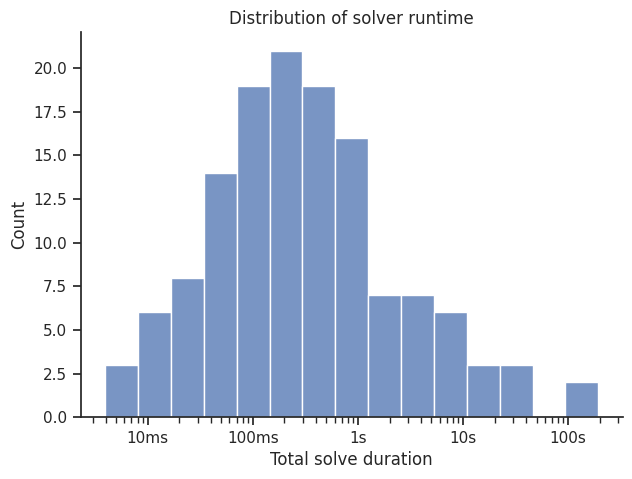

In [20]:
f, ax = plt.subplots(figsize=(7, 5))
sns.set_theme(style="ticks")
sns.despine(f)
sns.histplot(solve_total_duration, ax=ax, bins=15, log_scale=True)
ax.set_title("Distribution of solver runtime")
ax.set_xlabel("Total solve duration")
ax.xaxis.set_major_formatter(mpl.ticker.ScalarFormatter())
ax.set_xticks([1e4, 1e5, 1e6, 1e7, 1e8])
ax.set_xticklabels(['10ms', '100ms', '1s', '10s', '100s'])

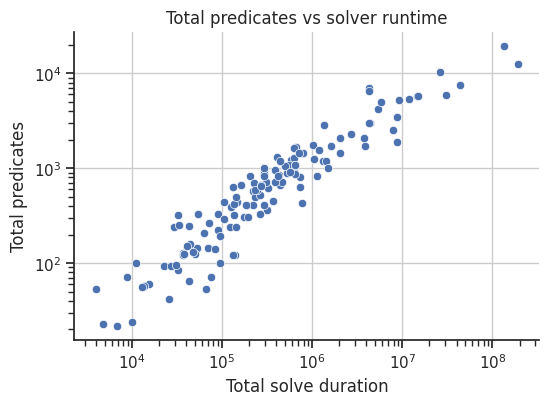

In [8]:
# Scatter plot of total predicates vs solve duration
f, ax = plt.subplots(figsize=(6, 4))
sns.set_theme(style="ticks")
sns.despine(f)
sns.scatterplot(y=dd_total_preds, x=solve_total_duration, ax=ax)
ax.set_title("Total predicates vs solver runtime")
ax.set_xlabel("Total solve duration")
ax.set_ylabel("Total predicates")
ax.set_xscale('log')
ax.set_yscale('log')
ax.grid()

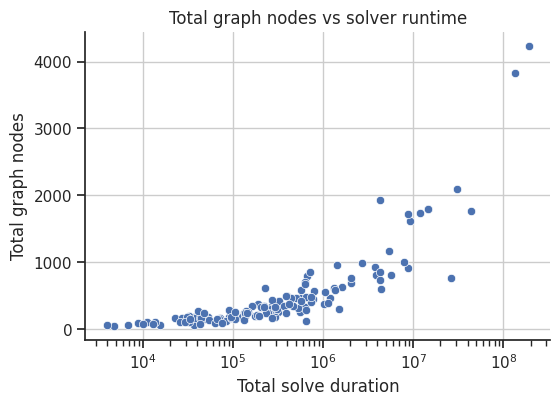

In [9]:
# Scatter plot of total graph nodes vs solve duration
f, ax = plt.subplots(figsize=(6, 4))
sns.set_theme(style="ticks")
sns.despine(f)
sns.scatterplot(y=ggraph_total_nodes, x=solve_total_duration, ax=ax)
ax.set_title("Total graph nodes vs solver runtime")
ax.set_xlabel("Total solve duration")
ax.set_ylabel("Total graph nodes")
ax.set_xscale('log')
ax.grid()

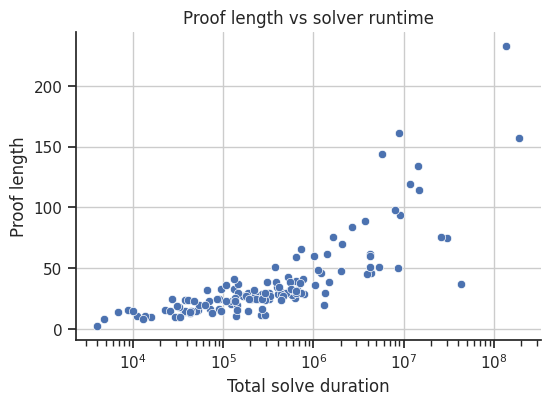

In [10]:
# Scatter plot of proof length vs solve duration
f, ax = plt.subplots(figsize=(6, 4))
sns.set_theme(style="ticks")
sns.despine(f)
sns.scatterplot(y=tr_sol_length, x=solve_total_duration, ax=ax)
ax.set_title("Proof length vs solver runtime")
ax.set_xlabel("Total solve duration")
ax.set_ylabel("Proof length")
ax.set_xscale('log')
ax.grid()

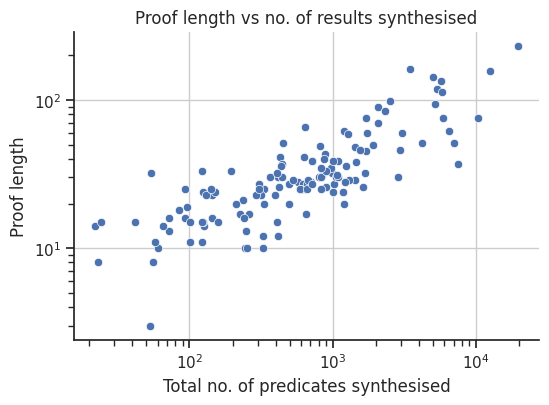

In [11]:
# Scatter plot of proof length vs no. of results synthesised
f, ax = plt.subplots(figsize=(6, 4))
sns.set_theme(style="ticks")
sns.despine(f)
sns.scatterplot(y=tr_sol_length, x=dd_total_preds, ax=ax)
ax.set_title("Proof length vs no. of results synthesised")
ax.set_xlabel("Total no. of predicates synthesised")
ax.set_ylabel("Proof length")
ax.set_xscale('log')
ax.set_yscale('log')
ax.grid()

In [12]:
df["dd_", "thm_duration"]

/tmp/ipykernel_439553/1499160504.py:1: PerformanceWarning: indexing past lexsort depth may impact performance.
  df["dd_", "thm_duration"]


Metric,circle_coll_perp,circle_cong,circle_eqangle_perp,circle_perp_eqangle,coll_coll_ncoll_diffside_p_diffside_p_eqratio_cyclic,coll_coll_ncoll_diffside_p_diffside_p_eqratio_simtri,coll_coll_ncoll_para_cong_cong_para,coll_coll_ncoll_para_eqratio_para,coll_coll_ncoll_sameside_p_sameside_p_eqratio_cyclic,cong_cong_cong_ncoll_contri,...,para_coll_coll_ncoll_simtri,para_coll_ncoll_eqangle,para_diff_coll,para_para_eqangle_ncoll_simtri,para_para_ncoll_cong,para_para_para_ncoll_simtri,perp_midp_cong,perp_perp_diff_cyclic,perp_perp_diff_perp,perp_perp_ncoll_para
imo-2000-1,"[8, 179, 181, 201]","[1, 50, 49, 59]","[0, 46909, 45886, 107087]","[0, 211, 203, 259]","[1258, 3658, 3282, 3458]","[1311, 1331, 3770, 3759, 6689, 6723, 6910, 6945]","[10480, 26739, 25648, 37219]","[12706, 26912, 25586, 32391]","[1357, 3962, 3538, 4030]","[1469, 1874, 4833, 4744]",...,"[89, 517, 356, 413]","[228, 322, 316, 370]","[53, 28, 28, 37]","[127, 1885, 2570, 3188]","[93, 246, 261, 318]","[112, 1514, 2182, 2745]","[59, 126, 128, 234]","[93, 201, 190, 432]","[303, 1143, 1120, 1790]","[925, 7588, 7409, 12753]"
imo-2002-2a,"[8, 71, 430]","[1, 34, 138]","[1, 3168, 308221]","[1, 51, 348]","[150, 137, 161]","[146, 129, 158, 141, 193, 164]","[461, 472, 462]","[469, 458, 458]","[139, 150, 171]","[4414, 6889, 11699]",...,"[28, 127, 125]","[93, 367, 125]","[5, 23, 22]","[81, 835, 952]","[21, 350, 88]","[66, 852, 830]","[88, 78, 99]","[69, 302, 1099]","[132, 321, 429]","[308, 702, 865]"
imo-2002-2b,"[11, 81]","[2, 22]","[1, 3159]","[2, 51]","[172, 144]","[169, 168, 150, 151]","[582, 467]","[550, 463]","[157, 130]","[4486, 7002]",...,"[28, 126]","[95, 279]","[6, 22]","[79, 836]","[22, 337]","[65, 850]","[87, 68]","[69, 298]","[132, 322]","[306, 689]"
imo-2003-4,"[37, 420, 402]","[8, 127, 118]","[17, 364018, 436686]","[19, 369, 337]","[4422, 5623, 4974]","[4733, 4765, 5600, 5685, 12276, 12192]","[48578, 49790, 51161]","[46506, 49172, 51495]","[4827, 6205, 5710]","[3105, 3593, 8990]",...,"[6, 292, 266]","[2, 173, 226]","[2, 18, 146]","[2, 984, 2110]","[2, 130, 241]","[2, 807, 1724]","[120, 438, 608]","[806, 3429, 1910]","[773, 4154, 4183]","[3155, 27955, 27477]"
imo-2004-1,"[54, 287, 250, 266]","[14, 76, 71, 79]","[126, 83143, 81504, 126647]","[34, 229, 204, 211]","[254, 327, 260, 258]","[281, 246, 377, 324, 567, 449, 567, 442]","[1142, 1259, 1195, 1174]","[1118, 1237, 1178, 1158]","[314, 393, 299, 290]","[2708, 3642, 4571, 4561]",...,"[6, 58, 72, 91]","[2, 57, 63, 91]","[2, 14, 14, 63]","[3, 265, 287, 535]","[2, 56, 63, 93]","[3, 235, 259, 462]","[4, 114, 139, 130]","[2, 459, 290, 273]","[2, 761, 787, 747]","[2, 2196, 2267, 2153]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110-104,"[10, 5, 40]","[1, 1, 12]","[1, 1, 1147]","[1, 1, 51]","[2731, 4889, 5429]","[3342, 4312, 6697, 6676, 10627, 7680]","[25967, 57818, 58496]","[24439, 56458, 56112]","[3219, 5756, 7009]","[153, 392, 530]",...,"[200, 394, 150]","[396, 157, 161]","[46, 13, 14]","[61, 246, 244]","[56, 68, 70]","[52, 219, 225]","[174, 173, 214]","[260, 607, 458]","[640, 1073, 1112]","[3001, 5701, 5824]"
110-107,"[8, 8, 4, 7]","[2, 2, 1, 2]","[1, 1, 1, 2]","[1, 1, 1, 1]","[4, 5, 3, 6]","[1, 2, 2, 1, 1, 1, 2, 2]","[1, 2, 1, 2]","[2, 2, 1, 2]","[1, 1, 1, 2]","[4, 8, 4, 7]",...,"[38, 31, 33, 56]","[25, 22, 22, 46]","[9, 8, 8, 13]","[103, 83, 86, 227]","[30, 28, 27, 330]","[82, 70, 73, 187]","[67, 57, 57, 60]","[61, 50, 51, 55]","[252, 210, 218, 235]","[630, 629, 647, 683]"
110-108,"[7, 8, 4]","[2, 2, 1]","[2, 2, 1]","[2, 2, 1]","[377, 451, 346]","[463, 486, 534, 544, 651, 682]","[3015, 3320, 2696]","[3448, 3551, 2793]","[623, 585, 342]","[9, 180, 159]",...,"[7, 9, 7]","[2, 3, 4]","[2, 3, 3]","[2, 3, 4]","[2, 3, 3]","[2, 3, 3]","[43, 86, 114]","[95, 298, 298]","[216, 479, 489]","[515, 1176, 1188]"
110-109,"[210, 228, 315, 347, 337]","[286, 73, 350, 110, 109]","[73, 71990, 160001, 238430, 584088]","[136, 174, 269, 306, 305]","[518, 547, 590, 574, 579]","[556, 483, 534, 522, 846,

/tmp/ipykernel_439553/3916995548.py:2: PerformanceWarning: indexing past lexsort depth may impact performance.
  df_thm_duration_per_problem = df[("dd_", "thm_duration")].map(sum)


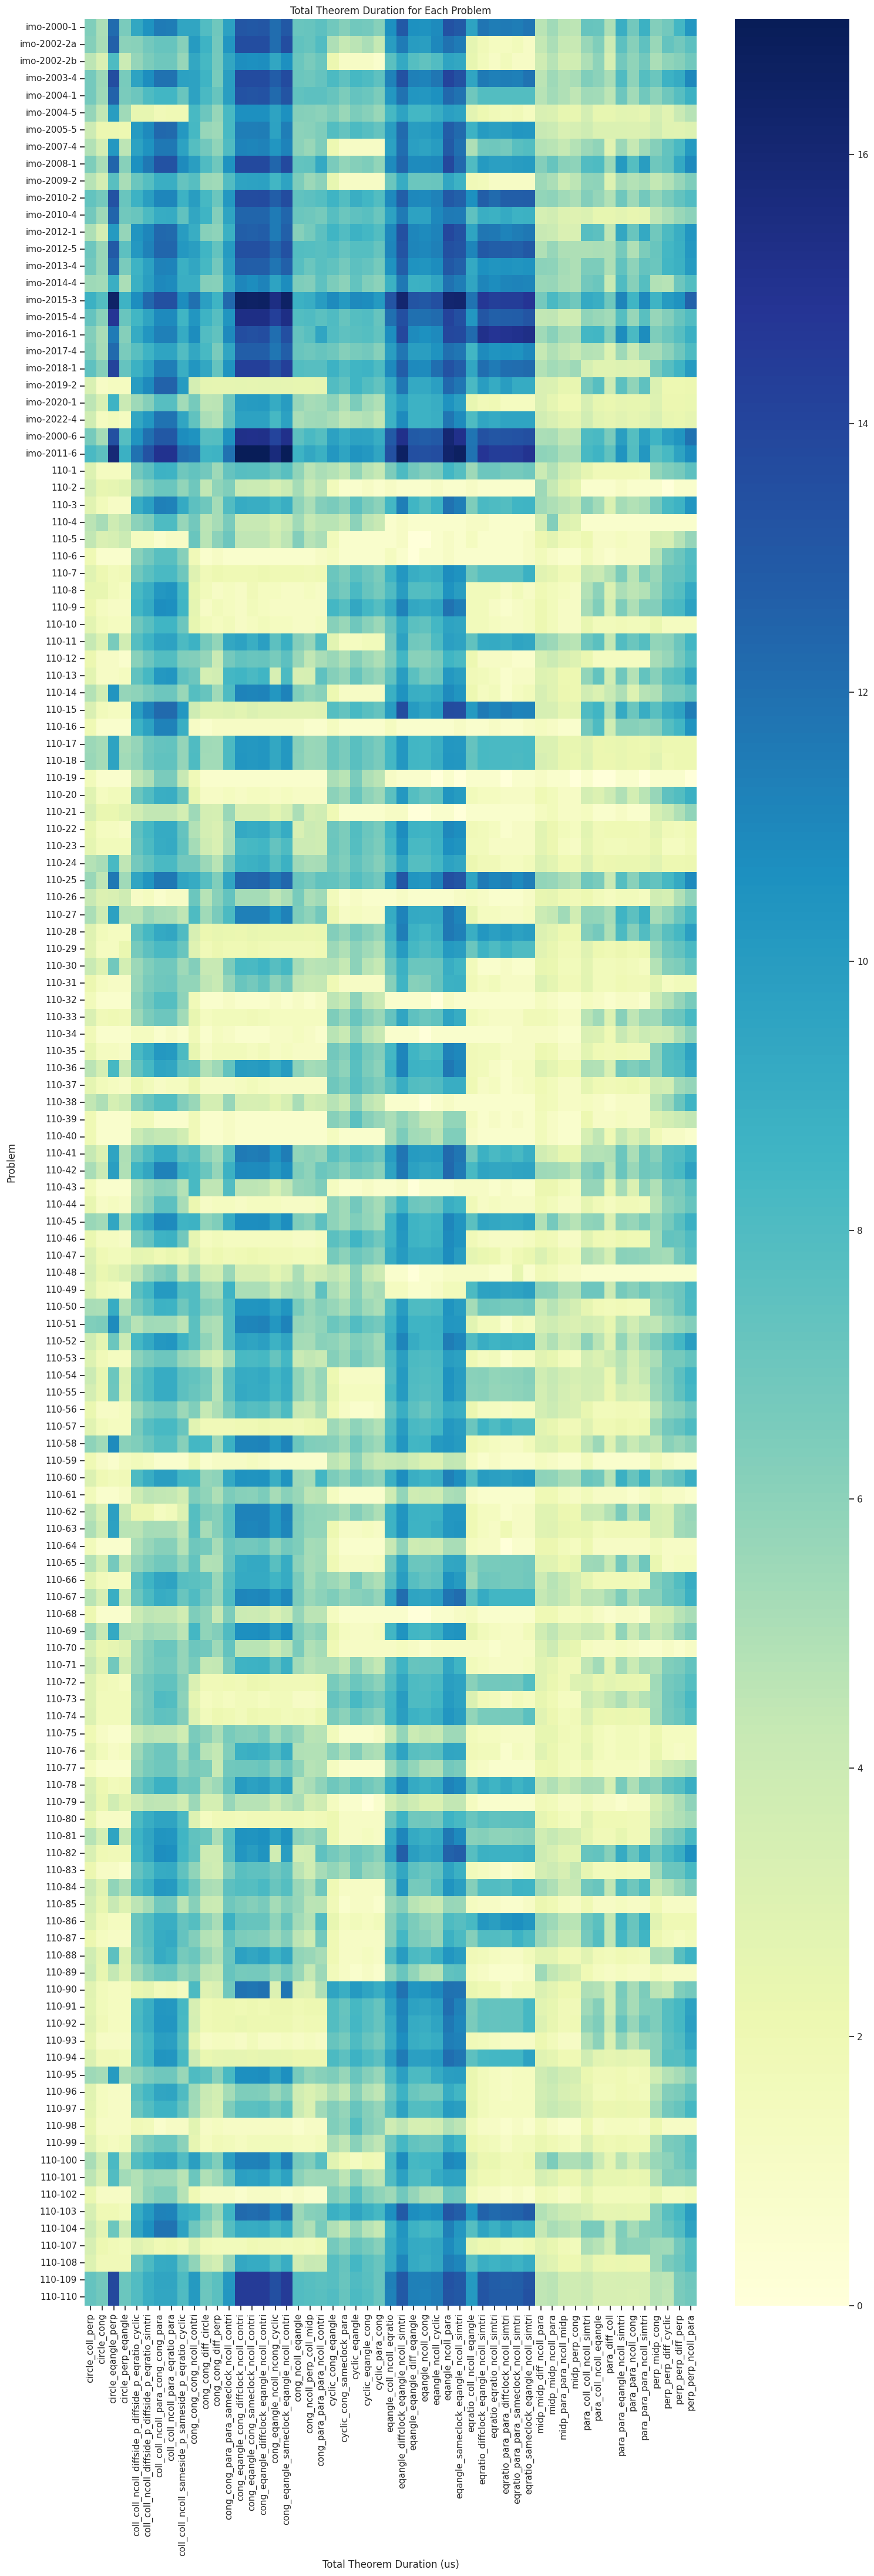

In [13]:
# Create another dataframe where every entry is equal to the sum of the elements in the list in df["dd_", "thm_duration"]
df_thm_duration_per_problem = df[("dd_", "thm_duration")].map(sum)

# Plot a heatmap of df_thm_duration_per_problem, with the index as the y-axis and the values as the x-axis
plt.figure(figsize=(15,N // 3))
sns.heatmap(np.log(df_thm_duration_per_problem + 1), annot=False, fmt=".1f", cmap="YlGnBu")
plt.xlabel("Total Theorem Duration (us)")
plt.ylabel("Problem")
plt.title("Total Theorem Duration for Each Problem")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [14]:
df_thm_duration_sum = df_thm_duration_per_problem.sum()
df_thm_duration_sum.sort_values()

Metric
midp_perp_cong                                              6092
midp_para_para_ncoll_midp                                   7522
para_diff_coll                                              9109
midp_midp_diff_ncoll_para                                  10598
circle_cong                                                14233
midp_midp_ncoll_para                                       16184
circle_coll_perp                                           33802
circle_perp_eqangle                                        35012
para_para_ncoll_cong                                       39536
perp_midp_cong                                             48257
cong_cong_diff_perp                                        50231
para_coll_coll_ncoll_simtri                                54117
para_coll_ncoll_eqangle                                    66447
cong_ncoll_perp_coll_midp                                  68027
cong_ncoll_eqangle                                         73054
cyclic_para_cong  

In [15]:
df_thm_matches_sum = df[("dd_", "thm_matches")].map(sum).sum()
df_thm_matches_sum.sort_values()

/tmp/ipykernel_439553/2467157996.py:1: PerformanceWarning: indexing past lexsort depth may impact performance.
  df_thm_matches_sum = df[("dd_", "thm_matches")].map(sum).sum()


Metric
coll_coll_ncoll_para_eqratio_para                           0
eqangle_ncoll_para                                          0
perp_perp_ncoll_para                                        0
cyclic_cong_sameclock_para                                  4
coll_coll_ncoll_para_cong_cong_para                         4
midp_para_para_ncoll_midp                                   8
circle_coll_perp                                           12
cong_ncoll_perp_coll_midp                                  12
coll_coll_ncoll_diffside_p_diffside_p_eqratio_simtri       14
eqratio_coll_ncoll_eqangle                                 16
midp_perp_cong                                             22
circle_eqangle_perp                                        40
cyclic_eqangle_cong                                        45
coll_coll_ncoll_diffside_p_diffside_p_eqratio_cyclic       56
midp_midp_ncoll_para                                       56
cyclic_para_cong                                           64
c

In [16]:
outlier = (df_thm_duration_sum.values > 1e6) & (df_thm_matches_sum.values < 10)
print(sum(outlier))

4


Outlier problems with high theorem duration but low matches:
coll_coll_ncoll_para_cong_cong_para
coll_coll_ncoll_para_eqratio_para
eqangle_ncoll_para
perp_perp_ncoll_para


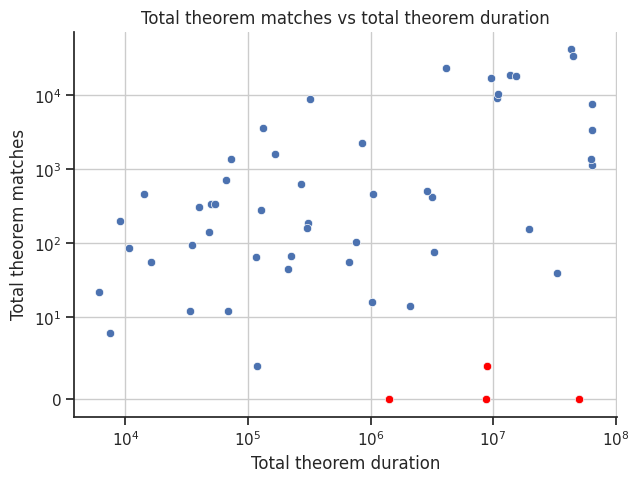

In [17]:
# Scatter plot of df_thm_matches_sum (y-axis) against df_thm_duration_sum (x-axis)
f, ax = plt.subplots(figsize=(7, 5))
sns.set_theme(style="ticks")
sns.despine(f)
sns.scatterplot(x=df_thm_duration_sum, y=df_thm_matches_sum, ax=ax)
sns.scatterplot(x=df_thm_duration_sum[outlier], y=df_thm_matches_sum[outlier], ax=ax, color='red')

ax.set_title("Total theorem matches vs total theorem duration")
ax.set_xlabel("Total theorem duration")
ax.set_ylabel("Total theorem matches")
ax.set_xscale('symlog', linthresh=10)
ax.set_yscale('symlog', linthresh=10)
ax.grid()

# Print out the outlier theorem names
print("Outlier problems with high theorem duration but low matches:")
for problem in df_thm_duration_sum.index[outlier]:
    print(problem)